In [28]:
import numpy as np
import pandas as pd

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = pd.read_csv("Indian_Kids_Screen_Time.csv")

print("Dataset loaded ")
print("Shape:", df.shape)
print(df.head())

Dataset loaded 
Shape: (9712, 8)
   Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0   14    Male                      3.99     Smartphone   
1   11  Female                      4.61         Laptop   
2   18  Female                      3.73             TV   
3   15  Female                      1.21         Laptop   
4   12  Female                      5.89     Smartphone   

   Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  \
0                        True                               0.42   
1                        True                               0.30   
2                        True                               0.32   
3                       False                               0.39   
4                        True                               0.49   

           Health_Impacts Urban_or_Rural  
0  Poor Sleep, Eye Strain          Urban  
1              Poor Sleep          Urban  
2              Poor Sleep          Urban  
3                     NaN      

In [31]:
## Device Mobility

df["Device_Mobility"] = df["Primary_Device"].map({
    "TV": "Wall-Mounted",
    "Desktop": "Fixed Device",
    "Laptop": "Portable",
    "Tablet": "Portable",
    "Smartphone": "Portable"
}).fillna("Unknown")

In [32]:
# Age Band using Age column

df["Age_Band"] = pd.cut(
    df["Age"],
    bins=[5, 8, 12, 16],
    labels=['Young Kids', 'Pre-Teens', 'Teenagers']
)
print(df["Age_Band"].value_counts())

Age_Band
Teenagers     3546
Pre-Teens     3495
Young Kids     912
Name: count, dtype: int64


In [44]:
## Usage Pattern

def classify_usage(ratio):
    if pd.isna(ratio):
        return "Unknown"
    elif ratio >= 1.2:
        return "Education Dominant"
    elif ratio <= 0.8:
        return "Recreation Dominant"
    else:
        return "Balanced Usage"

df["Usage_Pattern"] = df["Educational_to_Recreational_Ratio"].apply(classify_usage)


In [45]:
## WEEKEND/ WEEKDAYS
mean_screen_time = df["Avg_Daily_Screen_Time_hr"].mean()

df["Screen_Time_Type"] = np.where(
    df["Avg_Daily_Screen_Time_hr"] > mean_screen_time,
    "Heavy Usage",
    "Light Usage"
)

In [46]:
mean_usage = df["Avg_Daily_Screen_Time_hr"].mean()

df["Usage_Pattern"] = np.where(
    df["Avg_Daily_Screen_Time_hr"] > mean_usage,
    "Leisure-like",
    "Workday-like"
)

In [47]:
##health risk
df["Health_Impacts_Clean"] = (
    df["Health_Impacts"]
    .fillna("")
    .str.lower()
    .str.strip()
)

df.loc[df["Health_Impacts_Clean"] == "none", "Health_Impacts_Clean"] = ""

df["Health_Issue_Count"] = df["Health_Impacts_Clean"].apply(
    lambda x: 0 if x == "" else len([i.strip() for i in x.split(",")])
)

def health_risk_level(count):
    if count == 0:
        return "No Issues"
    elif count == 1:
        return "Mild Risk"
    elif count == 2:
        return "Moderate Risk"
    else:
        return "High Risk"

df["Health_Risk_Level"] = df["Health_Issue_Count"].apply(health_risk_level)



In [48]:
## final
df.to_csv("Indian_Kids_Screen_Time_Derived.csv", index=False)

print("All derived features created successfully!")
print(df.head(10))


All derived features created successfully!
   Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0   14    Male                      3.99     Smartphone   
1   11  Female                      4.61         Laptop   
2   18  Female                      3.73             TV   
3   15  Female                      1.21         Laptop   
4   12  Female                      5.89     Smartphone   
5   14  Female                      4.88     Smartphone   
6   17    Male                      2.97             TV   
7   10    Male                      2.74             TV   
8   14    Male                      4.61         Laptop   
9   18    Male                      3.24         Tablet   

   Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  \
0                        True                               0.42   
1                        True                               0.30   
2                        True                               0.32   
3                       False      

In [49]:
# Derive Health Risk directly (NO extra columns)

df["Health_Risk_Level"] = np.select(
    [
        df["Health_Impacts"].str.contains("Anxiety|Obesity Risk", case=False, na=False),
        df["Health_Impacts"].str.contains("Poor Sleep|Eye Strain", case=False, na=False),
        df["Health_Impacts"].str.contains("None", case=False, na=False)
    ],
    [
        "High Risk",
        "Medium Risk",
        "Low Risk"
    ],
    default="Medium Risk"
)

SINGLE NUMERICAL


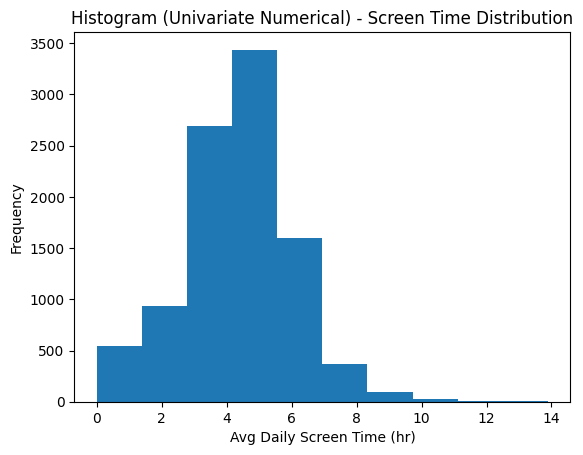

In [50]:
#  histogram
plt.figure()
plt.hist(df["Avg_Daily_Screen_Time_hr"], bins=10)
plt.title("Histogram (Univariate Numerical) - Screen Time Distribution")
plt.xlabel("Avg Daily Screen Time (hr)")
plt.ylabel("Frequency")
plt.show()

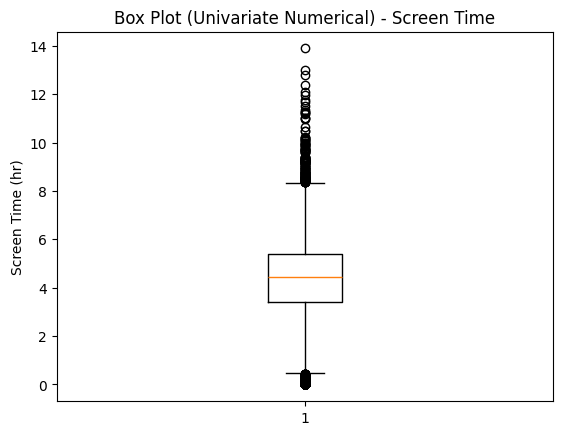

In [51]:
# Box Plot
plt.figure()
plt.boxplot(df["Avg_Daily_Screen_Time_hr"])
plt.title("Box Plot (Univariate Numerical) - Screen Time")
plt.ylabel("Screen Time (hr)")
plt.show()

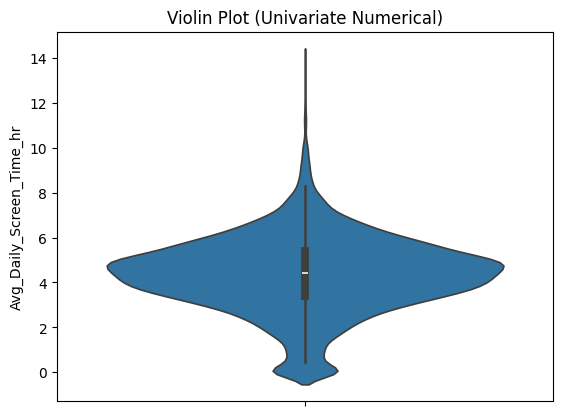

In [52]:
# Violin Plot
plt.figure()
sns.violinplot(y=df["Avg_Daily_Screen_Time_hr"])
plt.title("Violin Plot (Univariate Numerical)")
plt.show()

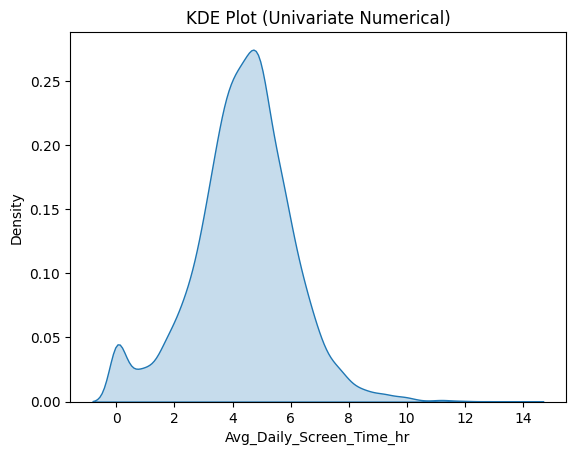

In [53]:
#  KDE Plot (Density Plot)
plt.figure()
sns.kdeplot(df["Avg_Daily_Screen_Time_hr"], fill=True)
plt.title("KDE Plot (Univariate Numerical)")
plt.show()

SINGLE CATEGORICAL COLUMN (Univariate – Categorical)

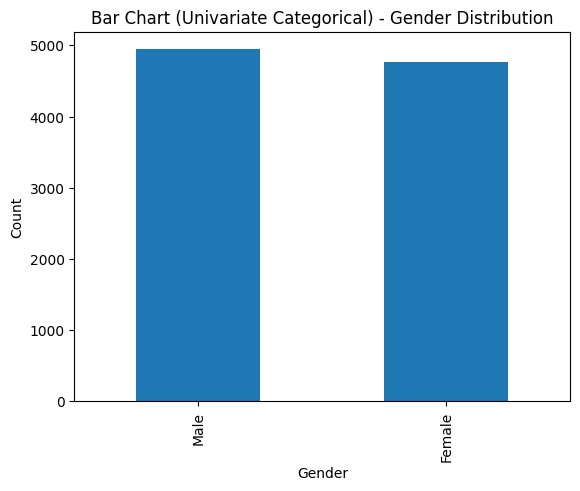

In [54]:
plt.figure()
df["Gender"].value_counts().plot(kind="bar")
plt.title("Bar Chart (Univariate Categorical) - Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

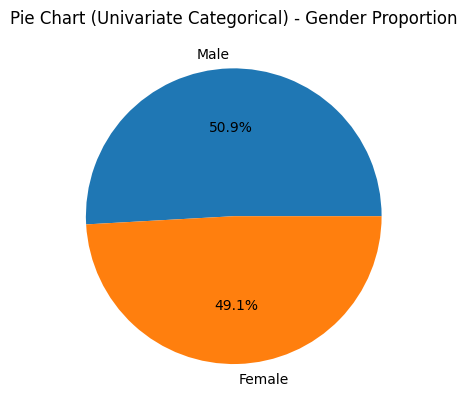

In [55]:
# Pie Chart
plt.figure()
df["Gender"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Pie Chart (Univariate Categorical) - Gender Proportion")
plt.ylabel("")
plt.show()

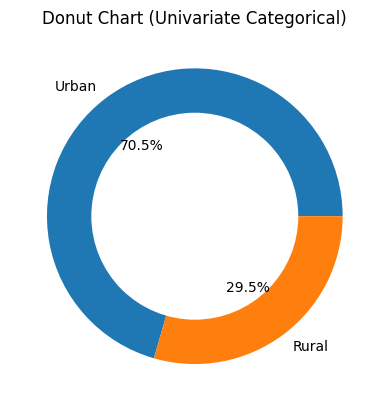

In [56]:
# Donut Chart
plt.figure()
counts = df["Urban_or_Rural"].value_counts()

plt.pie(counts, labels=counts.index, autopct="%1.1f%%")
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Donut Chart (Univariate Categorical)")
plt.show()

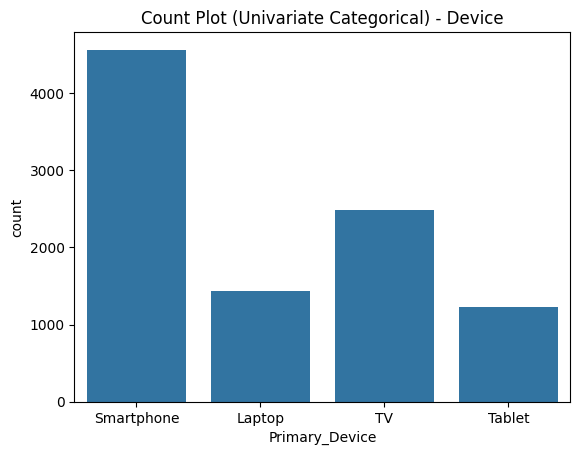

In [57]:
# Count Plot (Seaborn)
plt.figure()
sns.countplot(data=df, x="Primary_Device")
plt.title("Count Plot (Univariate Categorical) - Device")
plt.show()

NUMERICAL vs NUMERICAL (Bivariate – Numerical vs Numerical)

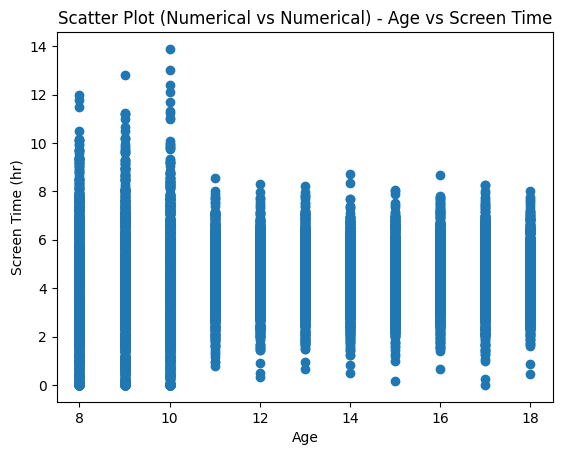

In [58]:
# Scatter Plot
plt.figure()
plt.scatter(df["Age"], df["Avg_Daily_Screen_Time_hr"])
plt.title("Scatter Plot (Numerical vs Numerical) - Age vs Screen Time")
plt.xlabel("Age")
plt.ylabel("Screen Time (hr)")
plt.show()

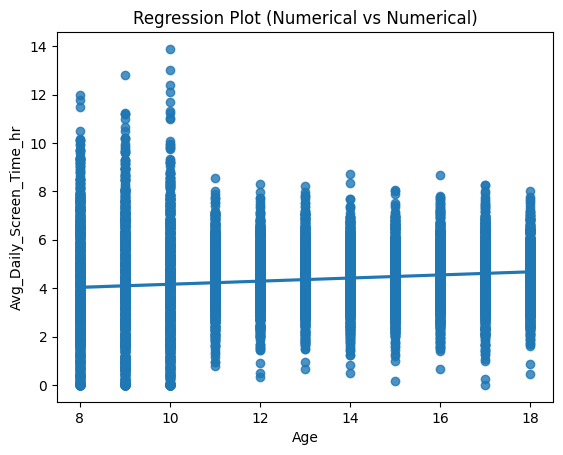

In [59]:
# Regression Plot
plt.figure()
sns.regplot(x="Age", y="Avg_Daily_Screen_Time_hr", data=df)
plt.title("Regression Plot (Numerical vs Numerical)")
plt.show()

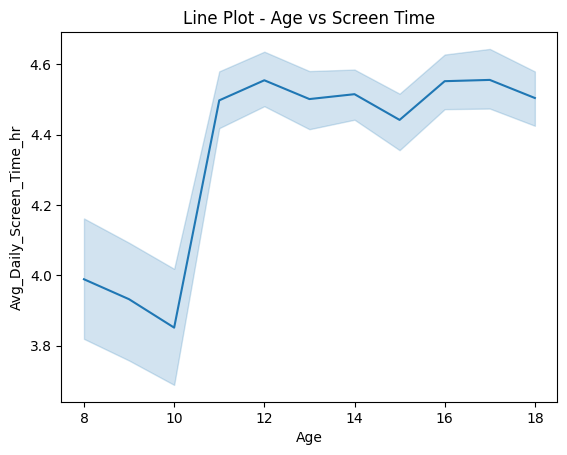

In [60]:
# Line Plot
plt.figure()
sns.lineplot(x="Age", y="Avg_Daily_Screen_Time_hr", data=df)
plt.title("Line Plot - Age vs Screen Time")
plt.show()

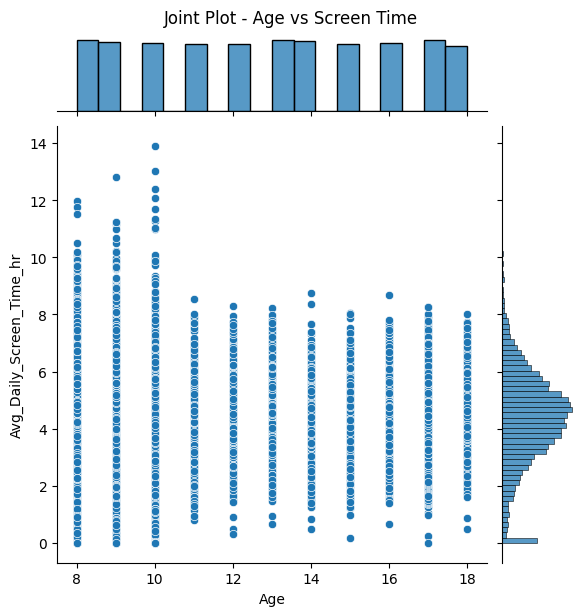

In [61]:
# Joint Plot
sns.jointplot(x="Age",
              y="Avg_Daily_Screen_Time_hr",
              data=df,
              kind="scatter")

plt.suptitle("Joint Plot - Age vs Screen Time", y=1.02)
plt.show()

NUMERICAL vs CATEGORICAL (Bivariate – Numerical vs Categorical)


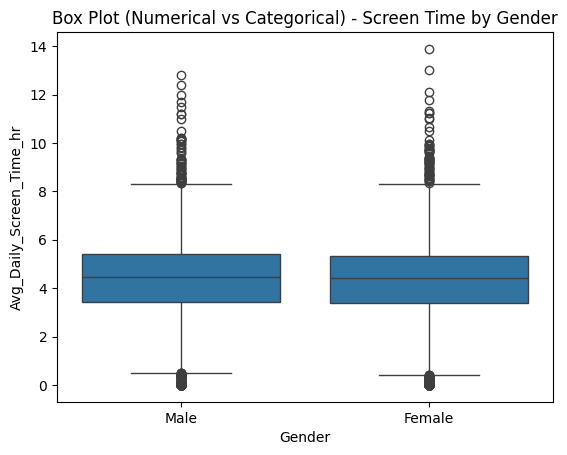

In [62]:
# Box Plot
plt.figure()
sns.boxplot(x="Gender", y="Avg_Daily_Screen_Time_hr", data=df)
plt.title("Box Plot (Numerical vs Categorical) - Screen Time by Gender")
plt.show()

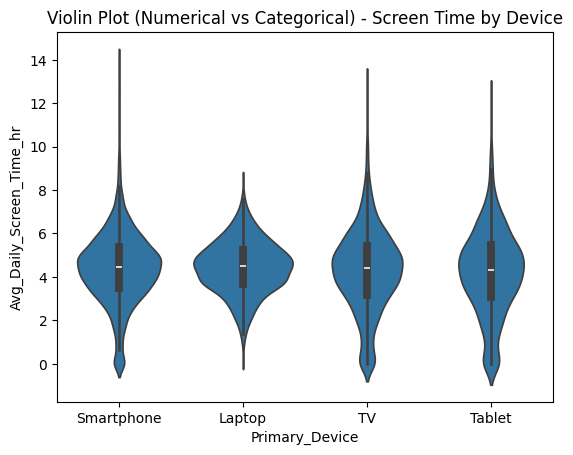

In [63]:
# Violin Plot
plt.figure()
sns.violinplot(x="Primary_Device", y="Avg_Daily_Screen_Time_hr", data=df)
plt.title("Violin Plot (Numerical vs Categorical) - Screen Time by Device")
plt.show()

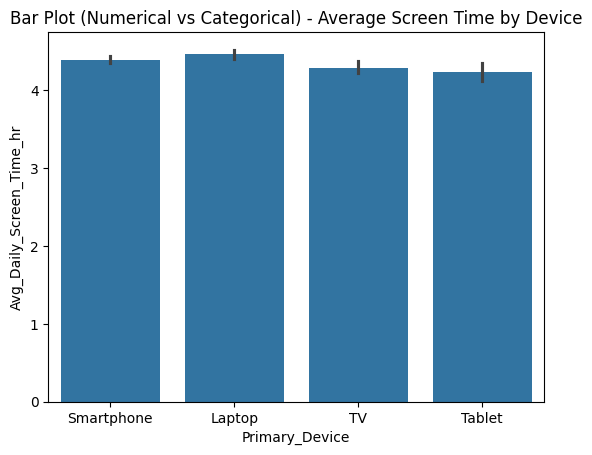

In [64]:
# Bar Plot (Mean Comparison)
plt.figure()
sns.barplot(x="Primary_Device", y="Avg_Daily_Screen_Time_hr", data=df)
plt.title("Bar Plot (Numerical vs Categorical) - Average Screen Time by Device")
plt.show()

CATEGORICAL vs CATEGORICAL (Bivariate – Categorical vs Categorical)



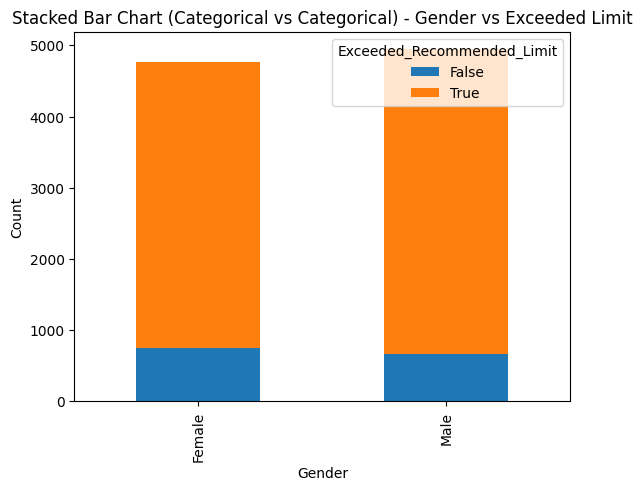

In [65]:
# Stacked Bar Chart
cross_tab = pd.crosstab(df["Gender"], df["Exceeded_Recommended_Limit"])

cross_tab.plot(kind="bar", stacked=True)
plt.title("Stacked Bar Chart (Categorical vs Categorical) - Gender vs Exceeded Limit")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

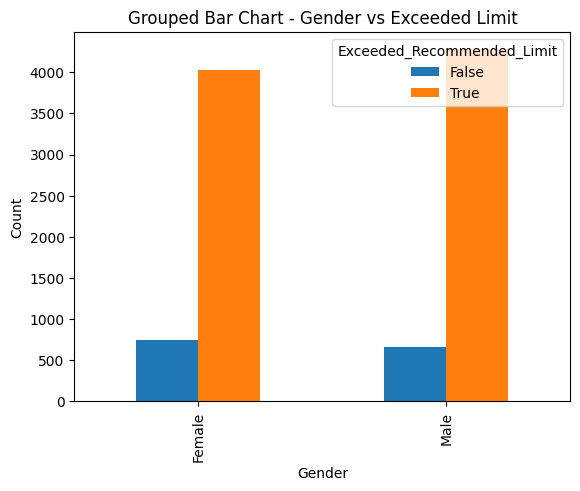

In [66]:
# Grouped Bar Chart
cross_tab = pd.crosstab(df["Gender"], df["Exceeded_Recommended_Limit"])

cross_tab.plot(kind="bar")
plt.title("Grouped Bar Chart - Gender vs Exceeded Limit")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()